# Point statistics

The `ps` (point statistics) module provides metrics to compare the mean spatial distribution of transcripts in relation to the centroid and the segmented outline of the cell. The idea of this module is to provide an intuition whether transcripts are distributed unequally, meaning they are more likely to have resulted from a spillover from neighbouring cells. The computed values can either be returned as a dictionary or stored in place in the `spatialdata` object.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import copy

import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

# Load spatial transcriptomics dataset and initalize SegTraQ object
sdata = sd.read_zarr("../../data/xenium.zarr")
# only looking at a subset for visualization purposes
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h
sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")
st = segtraq.SegTraQ(sdata, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid")

/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.__version__) >=

## Centroid mean coordinate difference

To assess the spatial distribution of a gene's transcripts within a cell, we can look at the "center of mass" of the transcripts and compare it to the centroid of the cell. 
The metric can either be computed per gene (as demonstrated below), or for all genes simultaneously (by using the `genes` argument). We compute the euclidean distance between the mean coordinate per transcript $\mu_{x,y}$ with the cell centroid coordinate $cc_{x,y}$ normalised by the cell area $|C|$. The normalisation by cell area is necessary because the computed euclidean distance scales with the cell area.

$$
d_{centroid-mean} = \frac{\sqrt{cc_{x,y}^2-\mu_{x,y}^2}}{|C|}
$$

In [3]:
# for one single gene
st.ps.centroid_mean_coord_diff("ERBB2")

,cell_id,distance_ERBB2
0,apheleok-1,6.688344
1,aphidfcb-1,11.157596
2,aphjeaih-1,2.742570
3,aphjibjb-1,2.453475
4,aphjipcp-1,4.533217
...,...,...
72,ipocgjja-1,3.878958
73,ipocjkfn-1,2.836878
74,ipoclfbi-1,2.634063
75,jaadeldi-1,4.404448


This result is also stored in `spatialdata` object and accesible in the observations of the `anndata` component.

In [4]:
sdata["table"].obs[sdata["table"].obs["distance_ERBB2"].notna()].head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,label_id,region,distance_ERBB2
3803,apheleok-1,985.953428,1191.931367,121,0,0,0,0,21,142,43.666095,25.287501,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3804,cell_boundaries,6.688344
3845,aphidfcb-1,847.619199,1204.688203,99,0,1,0,0,27,127,45.020783,18.649532,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3846,cell_boundaries,11.157596
3851,aphjeaih-1,896.131162,1176.530000,452,0,0,0,0,106,558,144.409693,102.865941,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3852,cell_boundaries,2.742570
3855,aphjibjb-1,902.833555,1185.372773,440,0,0,0,0,78,518,162.562506,68.502034,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3856,cell_boundaries,2.453475
3856,aphjipcp-1,906.314512,1173.572969,265,0,0,0,0,44,309,83.539066,58.657971,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3857,cell_boundaries,4.533217


We can visualise these results in space for the gene ERBB2

In [5]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_ERBB2"].notna()]

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.s

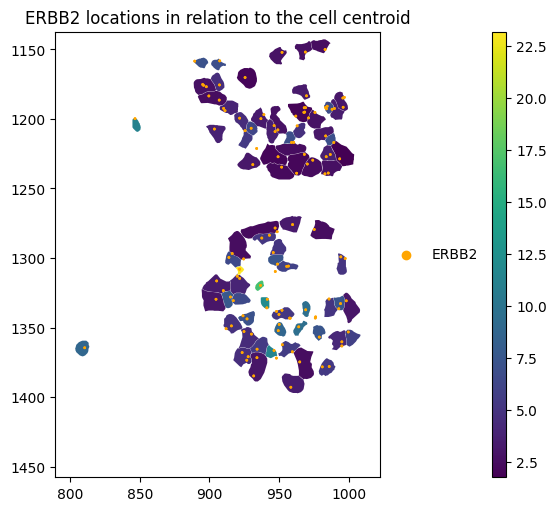

In [6]:
sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_ERBB2",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

We notice that there are some cells with a lot of cells at the boundary and some others that are more balanced.

## Distance to membrane

Another way to look at the spatial distribution of transcripts is the distance of a gene's transcripts to the membrane. In some sense, this is complementary to the `centroid_mean_coord_diff` metric. However, in the case of very irregularly shaped cells, the distance to the membrane is a more direct measure of unequal transcript distribution and hence potential spillover.  

The metric is defined as the mean distance to the cell membrane $\mu(d(m,t))$ (as provided in the `spatialdata` object) divided by the cell area $|C|$.
Again, this can be applied either to specific genes or all genes simultaneously.

$$
d_{membrane} = \frac{\mu(d(m,t))}{|C|}
$$

In [7]:
st.ps.distance_to_membrane("ERBB2")

,cell_id,distance_to_outline_ERBB2,distance_to_outline_norm_ERBB2,distance_to_outline_inverse_ERBB2
0,apheleok-1,1.002028,0.022948,0.998988
1,aphidfcb-1,0.046875,0.001041,4.618802
2,aphjeaih-1,4.259394,0.029495,0.484536
3,aphjibjb-1,3.361656,0.020679,0.545410
4,aphjipcp-1,3.252922,0.038939,0.554451
...,...,...,...,...
72,ipocgjja-1,1.651899,0.016194,0.778051
73,ipocjkfn-1,1.841699,0.018224,0.736870
74,ipoclfbi-1,1.104993,0.011261,0.951306
75,jaadeldi-1,1.513872,0.011014,0.812747


Also this result is also stored in spatialdata object and accesible in the observations of the anndata component.

In [8]:
sdata["table"].obs[
    sdata["table"].obs["distance_to_outline_ERBB2"].notna()
    | sdata["table"].obs["distance_to_outline_inverse_ERBB2"].notna()
]

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,label_id,region,distance_ERBB2,distance_to_outline_ERBB2,distance_to_outline_norm_ERBB2,distance_to_outline_inverse_ERBB2
3803,apheleok-1,985.953428,1191.931367,121,0,0,0,0,21,142,43.666095,25.287501,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3804,cell_boundaries,6.688344,1.002028,0.022948,0.998988
3845,aphidfcb-1,847.619199,1204.688203,99,0,1,0,0,27,127,45.020783,18.649532,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3846,cell_boundaries,11.157596,0.046875,0.001041,4.618802
3851,aphjeaih-1,896.131162,1176.530000,452,0,0,0,0,106,558,144.409693,102.865941,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3852,cell_boundaries,2.742570,4.259394,0.029495,0.484536
3855,aphjibjb-1,902.833555,1185.372773,440,0,0,0,0,78,518,162.562506,68.502034,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3856,cell_boundaries,2.453475,3.361656,0.020679,0.545410
3856,aphjipcp-1,906.314512,1173.572969,265,0,0,0,0,44,309,83.539066,58.657971,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3857,cell_boundaries,4.533217,3.252922,0.038939,0.554451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15354,ipocgjja-1,914.939512,1191.996797,285,0,0,0,0,46,331,102.007972,53.329533,1,Segmented by interior stain (18S),15355,cell_boundaries,3.878958,1.651899,0.016194,0.778051
15357,ipocjkfn-1,949.197324,1154.718477,282,0,0,0,0,66,348,101.059691,54.142346,1,Segmented by interior stain (18S),15358,cell_boundaries,2.836878,1.841699,0.018224,0.736870
15358,ipoclfbi-1,967.801328,1150.317109,254,0,0,0,0,46,300,98.124535,62.812346,1,Segmented by interior stain (18S),15359,cell_boundaries,2.634063,1.104993,0.011261,0.951306
15762,jaadeldi-1,927.810605,1357.838594,406,0,0,0,0,46,452,137.455630,75.636721,1,Segmented by interior stain (18S),15763,cell_boundaries,4.404448,1.513872,0.011014,0.812747


We can also plot this metric in space.

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.s

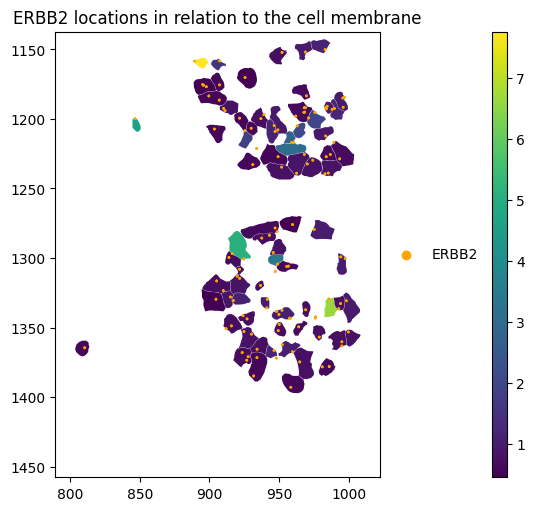

In [9]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_to_outline_inverse_ERBB2"].notna()]

sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_outline_inverse_ERBB2",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 locations in relation to the cell membrane",
    coordinate_systems="global",
    figsize=(10, 5),
)

We note that the two metrics are complementary to each other. However, there are situations with irregularly shaped cells where the distance to the centroid might be very small although the transcripts are clearly on the boarder of the cell.

## Periphery Enrichment Score

We can also compute the periphery enrichment score. For each cell, we divide the cell into an outer halo (erosion by 30% of the radius) and an inner part. We then aggregate all genes, and count how many transcripts we see on the inner vs. outer part. Both of these then are divided by their area to get the density. The rationale is, that a higher density of transcripts in the outer region could be due to spillover. Finally, we take the ratio of the border density vs. the inner density. If this is 1, our densities are equal. A value below one indicates a higher concentration of transcripts in the nucleus, whereas a value above one indicates higher transcript density in the outer region of the cell. This can be computed for individual genes as well as all genes (with the `genes` argument).

To avoid division by 0, pseudocounts are added if there is at least 1 transcript assigned to the cell. If both the border and the center expression are 0, we set the density ratio to NaN.

In [14]:
# the score we are interested in here is the "density_ratio"
periphery_df = st.ps.periphery_enrichment_score("ERBB2")
periphery_df.head()

,cell_id,center_expr_ERBB2,border_expr_ERBB2,center_area_ERBB2,border_area_ERBB2,border_density_ERBB2,center_density_ERBB2,density_ratio_ERBB2
0,aphcnklp-1,0,0,23.560789,26.720265,0.037425,0.042443,NaN
1,aphdnoam-1,0,0,12.014023,15.191087,0.065828,0.083236,NaN
2,aphdpfhl-1,0,0,37.536276,52.482329,0.019054,0.026641,NaN
3,aphebebn-1,0,0,77.656057,101.160773,0.009885,0.012877,NaN
4,aphejokb-1,0,0,36.136216,49.975528,0.020010,0.027673,NaN


INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.s

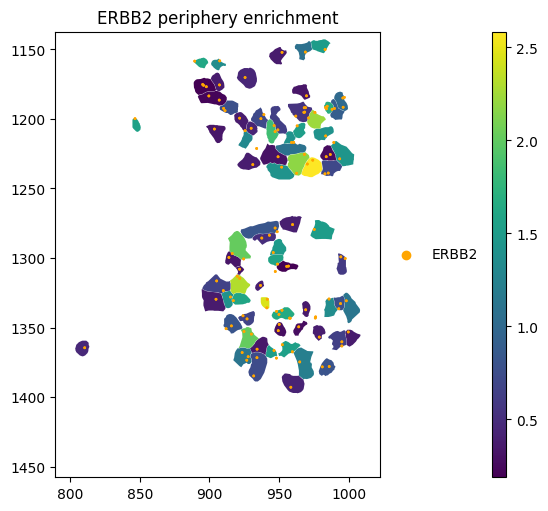

In [15]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["density_ratio_ERBB2"].notna()]

sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="density_ratio_ERBB2",
    cmap="viridis",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 periphery enrichment",
    coordinate_systems="global",
    figsize=(10, 5),
)

## Comparing the three metrics

Let's look at all three metrics right next to one another. We will only consider the metrics computed on all transcripts here, and not look at individual genes.

In [16]:
_ = st.ps.centroid_mean_coord_diff()
_ = st.ps.distance_to_membrane()
_ = st.ps.periphery_enrichment_score()

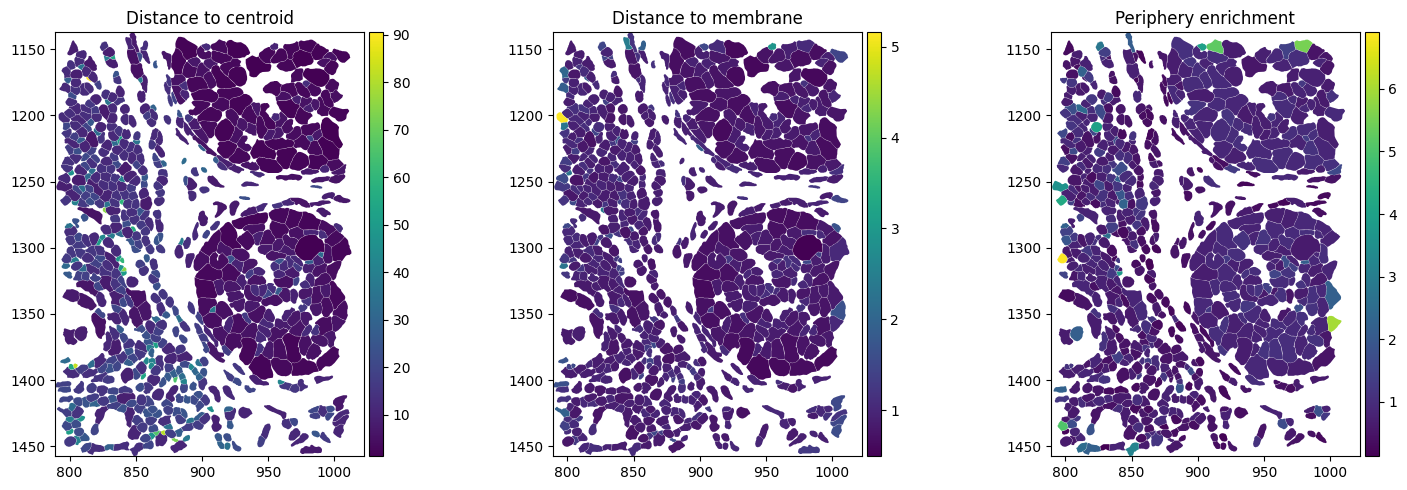

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# periphery enrichment
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_all_genes"].notna()]
sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="distance_all_genes",
).pl.show(
    title="Distance to centroid",
    coordinate_systems="global",
    ax=ax[0],
)

# periphery enrichment
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_to_outline_inverse_all_genes"].notna()]
sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_outline_inverse_all_genes",
).pl.show(
    title="Distance to membrane",
    coordinate_systems="global",
    ax=ax[1],
)

# periphery enrichment
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["density_ratio_all_genes"].notna()]
sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="density_ratio_all_genes",
).pl.show(
    title="Periphery enrichment",
    coordinate_systems="global",
    ax=ax[2],
)

plt.tight_layout()